# LSTM + Augmentasi Data TimeGAN

**Tujuan:** Menguji apakah augmentasi data sintetis dari TimeGAN meningkatkan performa model LSTM dibanding baseline (data nyata saja).

**Alur:**
```
Real daily_sales.csv  ──────────────────────────────┐
   │ split 70/15/15 (kronologis)                   │
   ├─ real_train ──┬─ augmented_train → LSTM A     │
   │               └─ baseline_train  → LSTM B     │ Evaluasi pada
   ├─ real_val   (monitor early stopping)          ├─ real_test
   └─ real_test  ──────────────────────────────────┘
                      ↑
synthetic_daily.csv ──┘ (hanya ditambahkan ke train)
```

**Catatan penting:**
- Scaler di-fit **hanya** pada `real_train` → tidak ada kebocoran data sintetis ke normalisasi
- Test set **murni data nyata** → hasil evaluasi dapat diperbandingkan secara langsung
- Model disimpan di `Models/TimeGAN/`

---
## SECTION 0 — Setup & Konfigurasi

In [47]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# ── Path ─────────────────────────────────────────────────────────────────────
DAILY_CSV  = os.path.join('..', 'Data', 'Ekstrak',  'daily_sales.csv')
SYNTH_CSV  = os.path.join('..', 'Data', 'TimeGAN', 'synthetic_daily.csv')
MODEL_DIR  = os.path.join('..', 'Models', 'TimeGAN')
SCALER_DIR = os.path.join(MODEL_DIR, 'scalers')

os.makedirs(MODEL_DIR,  exist_ok=True)
os.makedirs(SCALER_DIR, exist_ok=True)

# ── Hyperparameter ────────────────────────────────────────────────────────────
LOOK_BACK    = 14
HORIZON      = 7
BATCH_SIZE   = 32
EPOCHS       = 100
SEED         = 42

# Rasio synthetic terhadap real_train (1.0 = 100%, 2.0 = 200%)
# Terlalu besar → model didominasi pola sintetis → val/test error membengkak
SYNTH_RATIO  = 1.5

FEATURES = [
    'revenue', 'transactions', 'qty_sold',
    'week_sin', 'week_cos', 'month_sin', 'month_cos',
    'dow_sin',  'dow_cos',  'is_ramadan'
]
N_FEATURES = len(FEATURES)

np.random.seed(SEED)

print('daily_sales.csv  ada?', os.path.exists(DAILY_CSV))
print('synthetic_daily  ada?', os.path.exists(SYNTH_CSV))
print(f'SYNTH_RATIO      : {SYNTH_RATIO}x real_train')

import tensorflow as tf
tf.random.set_seed(SEED)
print('TensorFlow:', tf.__version__)

daily_sales.csv  ada? True
synthetic_daily  ada? True
SYNTH_RATIO      : 1.5x real_train
TensorFlow: 2.21.0


---
## SECTION 1 — Load & Preprocessing Data

In [48]:
def add_cyclical_features(df):
    """Tambahkan fitur siklus kalender."""
    df = df.copy()
    df['week_sin']  = np.sin(2 * np.pi * df['week_of_year'] / 52)
    df['week_cos']  = np.cos(2 * np.pi * df['week_of_year'] / 52)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['dow_sin']   = np.sin(2 * np.pi * df['day_of_week'] / 5)
    df['dow_cos']   = np.cos(2 * np.pi * df['day_of_week'] / 5)
    return df


# ── 1. Data nyata ─────────────────────────────────────────────────────────────
df_real = pd.read_csv(DAILY_CSV, parse_dates=['date'])
df_real = df_real[df_real['revenue'] > 0].copy().sort_values('date').reset_index(drop=True)
df_real = add_cyclical_features(df_real)

n        = len(df_real)
n_train  = int(n * 0.70)
n_val    = int(n * 0.15)
n_test   = n - n_train - n_val

df_real_train = df_real.iloc[:n_train].copy()
df_real_val   = df_real.iloc[n_train : n_train + n_val].copy()
df_real_test  = df_real.iloc[n_train + n_val:].copy()

print(f'Real — total hari aktif : {n}')
print(f'  Train : {len(df_real_train)} hari  ({df_real_train.date.min().date()} – {df_real_train.date.max().date()})')
print(f'  Val   : {len(df_real_val)} hari  ({df_real_val.date.min().date()} – {df_real_val.date.max().date()})')
print(f'  Test  : {len(df_real_test)} hari  ({df_real_test.date.min().date()} – {df_real_test.date.max().date()})')

Real — total hari aktif : 314
  Train : 219 hari  (2024-08-26 – 2025-11-25)
  Val   : 47 hari  (2025-11-26 – 2026-04-07)
  Test  : 48 hari  (2026-04-08 – 2026-06-21)


In [49]:
# ── 2. Data sintetis ──────────────────────────────────────────────────────────
df_syn = pd.read_csv(SYNTH_CSV, parse_dates=['date'])
df_syn = add_cyclical_features(df_syn)

# Hanya pakai baris hari kerja sintetis (filter is_weekend == 0)
df_syn_active = df_syn[df_syn['is_weekend'] == 0].copy().reset_index(drop=True)

print(f'Synthetic — total baris : {len(df_syn)}')
print(f'Synthetic — hari kerja  : {len(df_syn_active)}')
print(f'Revenue sintetis — rata-rata : Rp {df_syn_active["revenue"].mean():,.0f}')
print(f'Revenue nyata    — rata-rata : Rp {df_real_train["revenue"].mean():,.0f}')

Synthetic — total baris : 5376
Synthetic — hari kerja  : 3906
Revenue sintetis — rata-rata : Rp 1,566,829
Revenue nyata    — rata-rata : Rp 1,511,879


In [50]:
# ── 3. Scaler — fit HANYA pada real_train (anti-kebocoran) ───────────────────
scaler = MinMaxScaler()
scaler.fit(df_real_train[FEATURES].values)

train_real_sc = scaler.transform(df_real_train[FEATURES].values)
val_sc        = scaler.transform(df_real_val[FEATURES].values)
test_sc       = scaler.transform(df_real_test[FEATURES].values)
train_syn_sc  = scaler.transform(df_syn_active[FEATURES].values)  # blok utuh, belum di-cap

# Scaler khusus revenue untuk inverse_transform
scaler_rev = MinMaxScaler()
scaler_rev.fit(df_real_train[['revenue']].values)

with open(os.path.join(SCALER_DIR, 'scaler_daily_timegan.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
with open(os.path.join(SCALER_DIR, 'scaler_revenue_timegan.pkl'), 'wb') as f:
    pickle.dump(scaler_rev, f)

print(f'Real train     : {len(train_real_sc)} hari')
print(f'Synthetic train: {len(train_syn_sc)} hari  (belum di-cap, diproses di Section 3)')

Real train     : 219 hari
Synthetic train: 3906 hari  (belum di-cap, diproses di Section 3)


---
## SECTION 2 — Visualisasi Perbandingan Distribusi

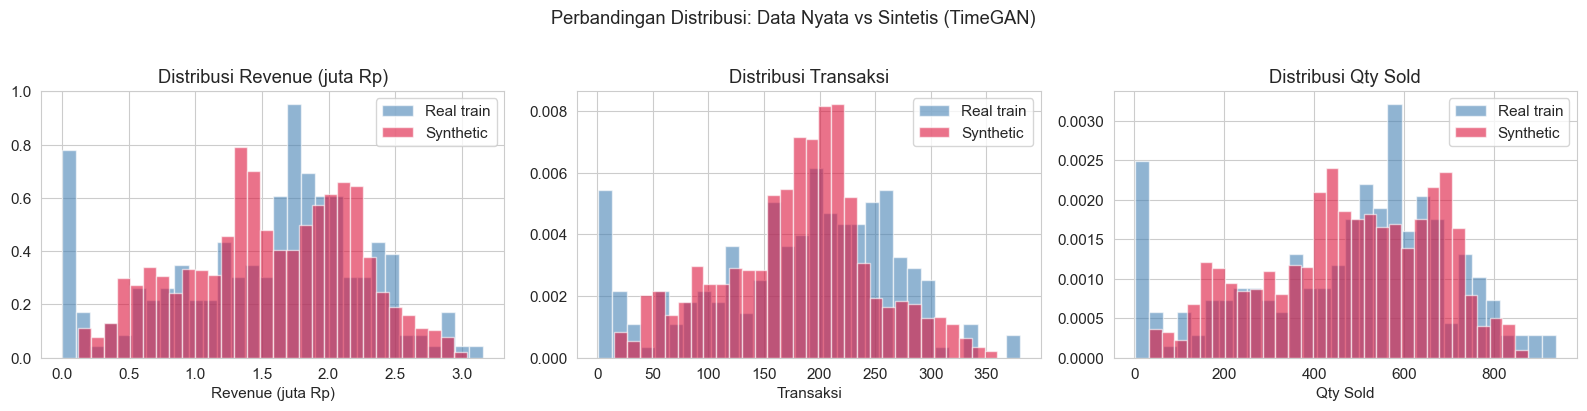

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
feature_labels = ['Revenue (juta Rp)', 'Transaksi', 'Qty Sold']
raw_cols       = ['revenue', 'transactions', 'qty_sold']
divisors       = [1e6, 1, 1]

for i, (col, label, div) in enumerate(zip(raw_cols, feature_labels, divisors)):
    axes[i].hist(df_real_train[col] / div, bins=30, alpha=0.6,
                 color='steelblue', label='Real train', density=True)
    axes[i].hist(df_syn_active[col] / div, bins=30, alpha=0.6,
                 color='crimson',   label='Synthetic',  density=True)
    axes[i].set_title(f'Distribusi {label}')
    axes[i].set_xlabel(label)
    axes[i].legend()

plt.suptitle('Perbandingan Distribusi: Data Nyata vs Sintetis (TimeGAN)', y=1.02)
plt.tight_layout()
plt.show()

---
## SECTION 3 — Pembentukan Sequence

In [52]:
def create_sequences(data, look_back, horizon, target_col=0):
    X, y = [], []
    for i in range(len(data) - look_back - horizon + 1):
        X.append(data[i : i + look_back])
        y.append(data[i + look_back : i + look_back + horizon, target_col])
    return np.array(X), np.array(y)


# ── Real sequences ─────────────────────────────────────────────────────────────
X_real, y_real = create_sequences(train_real_sc, LOOK_BACK, HORIZON)

# ── Synthetic sequences — window dulu dari blok utuh, baru pilih acak N seq ──
# Urutan penting: buat window dari data kontigu → tiap window berisi hari berurutan
X_syn_all, y_syn_all = create_sequences(train_syn_sc, LOOK_BACK, HORIZON)

# Pilih acak sejumlah SYNTH_RATIO × jumlah real sequences
max_syn_seqs = int(len(X_real) * SYNTH_RATIO)
if len(X_syn_all) > max_syn_seqs:
    chosen = np.random.choice(len(X_syn_all), max_syn_seqs, replace=False)
    X_syn = X_syn_all[chosen]
    y_syn = y_syn_all[chosen]
else:
    X_syn, y_syn = X_syn_all, y_syn_all

# ── Gabung + shuffle ───────────────────────────────────────────────────────────
X_train_aug = np.concatenate([X_real, X_syn], axis=0)
y_train_aug = np.concatenate([y_real, y_syn], axis=0)

perm        = np.random.permutation(len(X_train_aug))
X_train_aug = X_train_aug[perm]
y_train_aug = y_train_aug[perm]

# Baseline: hanya real
X_train_base, y_train_base = X_real.copy(), y_real.copy()

# Val & Test
X_val,  y_val  = create_sequences(val_sc,  LOOK_BACK, HORIZON)
X_test, y_test = create_sequences(test_sc, LOOK_BACK, HORIZON)

print(f'Real sequences       : {len(X_real)}')
print(f'Synthetic (all)      : {len(X_syn_all)}')
print(f'Synthetic (dipilih)  : {len(X_syn)}  ({SYNTH_RATIO}x × {len(X_real)} real seq)')
print(f'Augmented X_train    : {X_train_aug.shape}')
print(f'Baseline  X_train    : {X_train_base.shape}')
print(f'Val  X={X_val.shape}  |  Test X={X_test.shape}')

Real sequences       : 199
Synthetic (all)      : 3886
Synthetic (dipilih)  : 298  (1.5x × 199 real seq)
Augmented X_train    : (497, 14, 10)
Baseline  X_train    : (199, 14, 10)
Val  X=(27, 14, 10)  |  Test X=(28, 14, 10)


---
## SECTION 4 — Arsitektur & Training

In [53]:
def build_lstm(look_back, n_features, horizon, units=64, dropout=0.2):
    """Arsitektur identik dengan main.ipynb agar perbandingan adil."""
    model = Sequential([
        LSTM(units, return_sequences=True,
             input_shape=(look_back, n_features),
             kernel_regularizer=l2(1e-4)),
        Dropout(dropout),
        LSTM(units // 2, return_sequences=False,
             kernel_regularizer=l2(1e-4)),
        Dropout(dropout),
        Dense(32, activation='relu'),
        Dense(horizon)
    ], name=f'lstm_{look_back}lb_{horizon}h')
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


CALLBACKS = [
    EarlyStopping(monitor='val_loss', patience=15,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=7, min_lr=1e-6, verbose=1),
]

print('Builder siap.')

Builder siap.


### 4A — LSTM Augmented (Real + Synthetic TimeGAN)

In [54]:
print('=== Training LSTM Augmented (Real + TimeGAN) ===')
model_aug = build_lstm(LOOK_BACK, N_FEATURES, HORIZON)
model_aug.summary()

hist_aug = model_aug.fit(
    X_train_aug, y_train_aug,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=CALLBACKS,
    verbose=1
)

model_aug.save(os.path.join(MODEL_DIR, 'lstm_daily_timegan.keras'))
print('\nModel Augmented tersimpan:', os.path.join(MODEL_DIR, 'lstm_daily_timegan.keras'))

=== Training LSTM Augmented (Real + TimeGAN) ===


Model: "lstm_14lb_7h"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 14, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,903 (128.53 KB)

 Trainable params: 32,903 (128.53 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.1381 - mae: 0.2945 - val_loss: 0.1335 - val_mae: 0.3077 - learning_rate: 0.0010
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0732 - mae: 0.2055 - val_loss: 0.1289 - val_mae: 0.3064 - learning_rate: 0.0010
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0650 - mae: 0.1903 - val_loss: 0.1117 - val_mae: 0.2866 - learning_rate: 0.0010
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0634 - mae: 0.1891 - val_loss: 0.1054 - val_mae: 0.2797 - learning_rate: 0.0010
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0618 - mae: 0.1860 - val_loss: 0.0979 - val_mae: 0.2712 - learning_rate: 0.0010
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0594 - mae: 0.1832 - val_loss: 0.1014 - val_mae: 0.2759 - learning_rate: 0.0010
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0591 - mae: 0.1834 - val_loss: 0.0958 - val_mae: 0.2697 - learning_rate: 0.0010
Epoch 

### 4B — LSTM Baseline (Real Only)

In [55]:
print('=== Training LSTM Baseline (Real Only) ===')
model_base = build_lstm(LOOK_BACK, N_FEATURES, HORIZON)

hist_base = model_base.fit(
    X_train_base, y_train_base,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=CALLBACKS,
    verbose=1
)

model_base.save(os.path.join(MODEL_DIR, 'lstm_daily_baseline.keras'))
print('\nModel Baseline tersimpan:', os.path.join(MODEL_DIR, 'lstm_daily_baseline.keras'))

=== Training LSTM Baseline (Real Only) ===
Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 0.2486 - mae: 0.4264 - val_loss: 0.0678 - val_mae: 0.2110 - learning_rate: 0.0010
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1272 - mae: 0.2827 - val_loss: 0.1381 - val_mae: 0.3152 - learning_rate: 0.0010
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0931 - mae: 0.2335 - val_loss: 0.1468 - val_mae: 0.3220 - learning_rate: 0.0010
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0872 - mae: 0.2253 - val_loss: 0.1124 - val_mae: 0.2855 - learning_rate: 0.0010
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0769 - mae: 0.2131 - val_loss: 0.1021 - val_mae: 0.2730 - learning_rate: 0.0010
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0765 - mae: 0.2135 - val_loss: 0.1028 - val_mae: 0.2719 - learning_rate: 0.0010
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0730 - mae: 0.2061 
Epoch 7: ReduceLROnPlateau reducing le

---
## SECTION 5 — Evaluasi & Perbandingan

In [56]:
def inverse_revenue(arr_scaled, scaler_rev):
    s, h = arr_scaled.shape
    return scaler_rev.inverse_transform(arr_scaled.reshape(-1, 1)).reshape(s, h)


# Naive MAE in-sample (denominator MASE) — dihitung dari real_train
_rev_tr   = df_real_train['revenue'].values
naive_mae = np.mean(np.abs(np.diff(_rev_tr)))


def evaluate(model, X, y_scaled, scaler_rev, label=''):
    y_pred_sc = model.predict(X, verbose=0)
    y_pred    = inverse_revenue(y_pred_sc, scaler_rev)
    y_true    = inverse_revenue(y_scaled,  scaler_rev)

    yp, yt = y_pred.flatten(), y_true.flatten()

    rmse  = np.sqrt(mean_squared_error(yt, yp))
    mae   = mean_absolute_error(yt, yp)
    mask  = yt != 0
    mape  = np.mean(np.abs((yt[mask] - yp[mask]) / yt[mask])) * 100
    denom = (np.abs(yt) + np.abs(yp)) / 2
    smape = np.mean(np.abs(yt - yp) / np.where(denom == 0, 1, denom)) * 100
    mase  = mae / naive_mae

    # MAPE tidak stabil jika prediksi jauh meleset → tandai jika > 200%
    mape_flag = ' (!)' if mape > 200 else ''

    print(f'{label:30s}  RMSE: Rp {rmse:>11,.0f}  |  MAE: Rp {mae:>11,.0f}'
          f'  |  MAPE: {mape:7.2f}%{mape_flag}  |  sMAPE: {smape:6.2f}%  |  MASE: {mase:.4f}')
    return {'rmse': rmse, 'mae': mae, 'mape': mape, 'smape': smape, 'mase': mase,
            'y_pred': y_pred, 'y_true': y_true}


print(f'Naive MAE in-sample (denominator MASE): Rp {naive_mae:,.0f}')
print('Catatan: MAPE ditandai (!) jika > 200% — gunakan sMAPE sebagai metrik utama')
print()
print('=== Evaluasi pada Real Test Set ===')
print(f'{"":30s}  {"RMSE":>18}  {"MAE":>18}  {"MAPE":>12}  {"sMAPE":>8}  {"MASE":>7}')
print('-' * 110)
res_aug  = evaluate(model_aug,  X_test, y_test, scaler_rev, 'LSTM Augmented (+ TimeGAN)')
res_base = evaluate(model_base, X_test, y_test, scaler_rev, 'LSTM Baseline (Real Only)')

Naive MAE in-sample (denominator MASE): Rp 362,901
Catatan: MAPE ditandai (!) jika > 200% — gunakan sMAPE sebagai metrik utama

=== Evaluasi pada Real Test Set ===
                                              RMSE                 MAE          MAPE     sMAPE     MASE
--------------------------------------------------------------------------------------------------------------
LSTM Augmented (+ TimeGAN)      RMSE: Rp   1,047,842  |  MAE: Rp     860,695  |  MAPE:   72.19%  |  sMAPE:  41.49%  |  MASE: 2.3717
LSTM Baseline (Real Only)       RMSE: Rp   1,935,119  |  MAE: Rp   1,750,355  |  MAPE:   81.21%  |  sMAPE: 115.40%  |  MASE: 4.8232


=== Seasonal Naive — Test Set ===
                                                       MAE     sMAPE     MASE                RMSE
---------------------------------------------------------------------------------------------------------
Seasonal Naive m=5 (minggu lalu)        MAE: Rp     755,403  |  sMAPE:  37.58%  |  MASE: 2.0816  |  RMSE: Rp     975,130
Seasonal Naive m=7 (7 aktif-hari lalu)  MAE: Rp     783,179  |  sMAPE:  38.24%  |  MASE: 2.1581  |  RMSE: Rp     985,180

Catatan: m=5 = hari yang sama minggu lalu (5 hari kerja).
         Jika LSTM MASE < MASE SN5, model mengalahkan pola mingguan sederhana.

=== MASE per Horizon (h+1 … h+7) ===
 Horizon       Aug      Base      SN-5      SN-7         MAE Aug        MAE Base   sMAPE Aug
---------------------------------------------------------------------------------------------------------
  h+1        2.5053    3.9277    2.1403    2.2738  Rp     909,176  Rp   1,425,364      41.33%
  h+2        2.5632    4.7919    2.1393    2.2167  

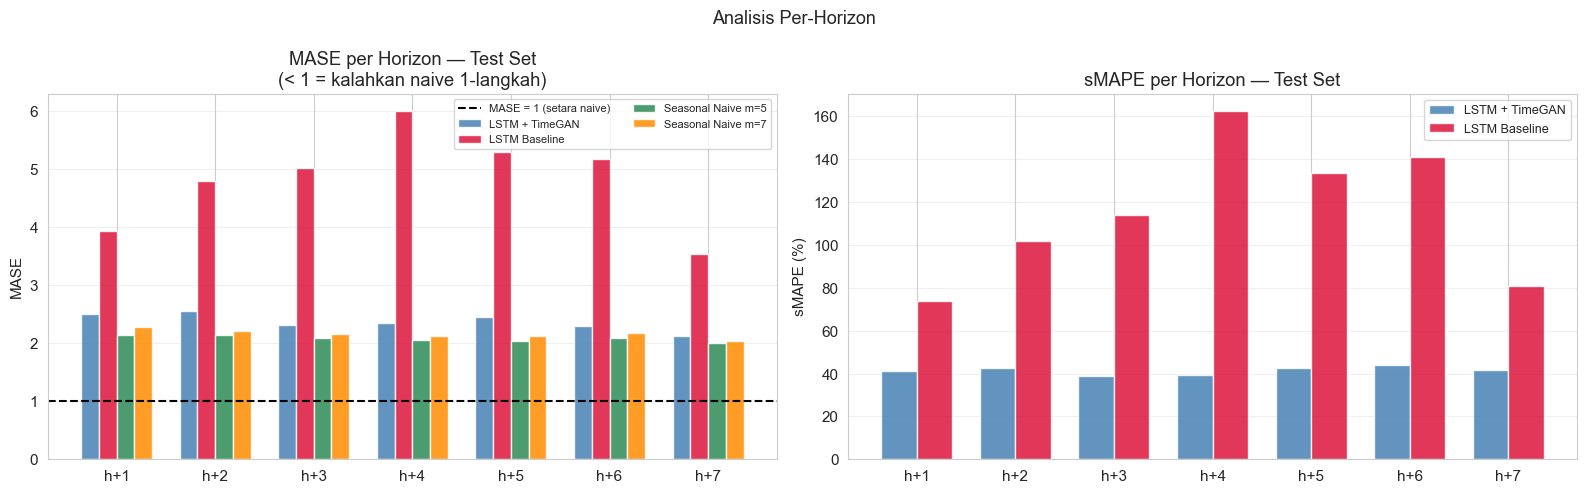

In [57]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 5B — Seasonal Naive Baseline + Per-Horizon MASE
# ═══════════════════════════════════════════════════════════════════════════════

# ── A. Seasonal Naive ─────────────────────────────────────────────────────────
# Prediksi hari ke-h = revenue dari m hari aktif sebelumnya (dalam df_real)
# m=5 → "hari yang sama minggu lalu" (5 hari kerja = 1 pekan bisnis)
# m=7 → 7 hari aktif lalu (toleransi libur/Ramadan yang memendekan pekan)

rev_all   = df_real['revenue'].values          # hanya hari aktif
y_true_rp = inverse_revenue(y_test, scaler_rev)  # (n_windows, HORIZON) dalam Rp

n_win    = len(X_test)
sn5_pred = np.zeros((n_win, HORIZON))
sn7_pred = np.zeros((n_win, HORIZON))

for i in range(n_win):
    for h in range(HORIZON):
        t = (n_train + n_val) + LOOK_BACK + i + h
        sn5_pred[i, h] = rev_all[max(0, t - 5)]
        sn7_pred[i, h] = rev_all[max(0, t - 7)]


def _eval_raw(yp_rp, yt_rp, label=''):
    """Evaluasi dalam Rupiah (tidak lewat scaler)."""
    yp, yt = yp_rp.flatten(), yt_rp.flatten()
    rmse  = np.sqrt(mean_squared_error(yt, yp))
    mae   = mean_absolute_error(yt, yp)
    mask  = yt != 0
    mape  = np.mean(np.abs((yt[mask] - yp[mask]) / yt[mask])) * 100
    denom = (np.abs(yt) + np.abs(yp)) / 2
    smape = np.mean(np.abs(yt - yp) / np.where(denom == 0, 1, denom)) * 100
    mase  = mae / naive_mae
    if label:
        mape_flag = ' (!)' if mape > 200 else ''
        print(f'{label:38s}  MAE: Rp {mae:>11,.0f}  |  sMAPE: {smape:6.2f}%  |  MASE: {mase:.4f}  |  RMSE: Rp {rmse:>11,.0f}')
    return {'rmse': rmse, 'mae': mae, 'mape': mape, 'smape': smape, 'mase': mase,
            'y_pred': yp_rp, 'y_true': yt_rp}


print('=== Seasonal Naive — Test Set ===')
print(f'{"":38s}  {"MAE":>18}  {"sMAPE":>8}  {"MASE":>7}  {"RMSE":>18}')
print('-' * 105)
res_sn5 = _eval_raw(sn5_pred, y_true_rp, 'Seasonal Naive m=5 (minggu lalu)')
res_sn7 = _eval_raw(sn7_pred, y_true_rp, 'Seasonal Naive m=7 (7 aktif-hari lalu)')

print()
print('Catatan: m=5 = hari yang sama minggu lalu (5 hari kerja).')
print('         Jika LSTM MASE < MASE SN5, model mengalahkan pola mingguan sederhana.\n')

# ── B. Per-Horizon MASE & sMAPE ───────────────────────────────────────────────
print('=== MASE per Horizon (h+1 … h+7) ===')
print(f'{"Horizon":>8}  {"Aug":>8}  {"Base":>8}  {"SN-5":>8}  {"SN-7":>8}'
      f'  {"MAE Aug":>14}  {"MAE Base":>14}  {"sMAPE Aug":>10}')
print('-' * 105)

ph_rows = []
for h in range(HORIZON):
    yt_h  = y_true_rp[:, h]
    ya_h  = res_aug['y_pred'][:, h]
    yb_h  = res_base['y_pred'][:, h]
    ys5_h = sn5_pred[:, h]
    ys7_h = sn7_pred[:, h]

    def _m(yp, yt): return mean_absolute_error(yt, yp) / naive_mae
    def _sm(yp, yt):
        d = (np.abs(yt) + np.abs(yp)) / 2
        return np.mean(np.abs(yt - yp) / np.where(d == 0, 1, d)) * 100

    ma, mb   = _m(ya_h, yt_h),   _m(yb_h, yt_h)
    ms5, ms7 = _m(ys5_h, yt_h),  _m(ys7_h, yt_h)
    mae_a    = mean_absolute_error(yt_h, ya_h)
    mae_b    = mean_absolute_error(yt_h, yb_h)
    sm_a     = _sm(ya_h, yt_h)

    flag = '  ◀ <1' if ma < 1.0 else ('  ◀ <SN5' if ma < ms5 else '')
    print(f'  h+{h+1}      {ma:8.4f}  {mb:8.4f}  {ms5:8.4f}  {ms7:8.4f}'
          f'  Rp {mae_a:>11,.0f}  Rp {mae_b:>11,.0f}  {sm_a:9.2f}%{flag}')

    ph_rows.append({
        'horizon': f'h+{h+1}',
        'mase_aug': ma, 'mase_base': mb, 'mase_sn5': ms5, 'mase_sn7': ms7,
        'mae_aug': mae_a, 'mae_base': mae_b, 'smape_aug': sm_a,
        'smape_base': _sm(yb_h, yt_h),
    })

ph_df = pd.DataFrame(ph_rows)

# ── Plot per-horizon ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x      = np.arange(HORIZON)
w      = 0.18
labels = [f'h+{i+1}' for i in range(HORIZON)]

ax = axes[0]
ax.bar(x - 1.5*w, ph_df['mase_aug'],  w, label='LSTM + TimeGAN',      color='steelblue', alpha=0.85)
ax.bar(x - 0.5*w, ph_df['mase_base'], w, label='LSTM Baseline',        color='crimson',   alpha=0.85)
ax.bar(x + 0.5*w, ph_df['mase_sn5'],  w, label='Seasonal Naive m=5',   color='seagreen',  alpha=0.85)
ax.bar(x + 1.5*w, ph_df['mase_sn7'],  w, label='Seasonal Naive m=7',   color='darkorange',alpha=0.85)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='MASE = 1 (setara naive)')
ax.set_xticks(x);  ax.set_xticklabels(labels)
ax.set_title('MASE per Horizon — Test Set\n(< 1 = kalahkan naive 1-langkah)')
ax.set_ylabel('MASE')
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3, axis='y')

ax = axes[1]
ax.bar(x - 0.5*w*2, ph_df['smape_aug'],  w*2, label='LSTM + TimeGAN', color='steelblue', alpha=0.85)
ax.bar(x + 0.5*w*2, ph_df['smape_base'], w*2, label='LSTM Baseline',  color='crimson',   alpha=0.85)
ax.set_xticks(x);  ax.set_xticklabels(labels)
ax.set_title('sMAPE per Horizon — Test Set')
ax.set_ylabel('sMAPE (%)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')

plt.suptitle('Analisis Per-Horizon', fontsize=13)
plt.tight_layout()
plt.show()

In [58]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 6X — HYBRID Seasonal-Residual LSTM (+ TimeGAN)
# Model meramal RESIDUAL di atas seasonal-naive m=5, bukan revenue mentah.
#   forecast_akhir = SN5 + LSTM_residual   →  model mulai dari baseline kuat,
#   hanya perlu belajar koreksinya, sehingga seharusnya menembus di bawah SN-5.
# ═══════════════════════════════════════════════════════════════════════════════
from sklearn.preprocessing import StandardScaler

M_SEASON = 5  # 5 hari kerja = 1 pekan bisnis (samakan dengan SN-5)

rev_real_full = df_real['revenue'].values          # (314,) hanya hari aktif
rev_syn       = df_syn_active['revenue'].values    # deret sintetis

# ── Helper: SN & residual untuk satu split (indeks global di df_real) ──────────
def sn_resid(n_windows, global_start, rev_series, m):
    sn  = np.zeros((n_windows, HORIZON))
    res = np.zeros((n_windows, HORIZON))
    for i in range(n_windows):
        for h in range(HORIZON):
            t = global_start + LOOK_BACK + i + h
            sn[i, h]  = rev_series[max(0, t - m)]
            res[i, h] = rev_series[t] - sn[i, h]
    return sn, res

# ── 1. Target residual tiap split (REUSE X_train_base / X_val / X_test) ────────
_,     resid_tr_real = sn_resid(len(X_train_base), 0,               rev_real_full, M_SEASON)
_,     resid_val     = sn_resid(len(X_val),        n_train,         rev_real_full, M_SEASON)
sn_te, resid_test    = sn_resid(len(X_test),       n_train + n_val, rev_real_full, M_SEASON)

# ── 2. Sintetis: window + residual, lalu subsample SYNTH_RATIO× ───────────────
X_syn_all, _     = create_sequences(train_syn_sc, LOOK_BACK, HORIZON)
_, resid_syn_all = sn_resid(len(X_syn_all), 0, rev_syn, M_SEASON)

n_syn = int(len(X_train_base) * SYNTH_RATIO)
sel   = np.random.choice(len(X_syn_all), min(n_syn, len(X_syn_all)), replace=False)
X_syn_h, resid_syn_sel = X_syn_all[sel], resid_syn_all[sel]

# ── 3. Augmented residual set (real + synthetic) + shuffle ─────────────────────
X_train_h     = np.concatenate([X_train_base, X_syn_h], axis=0)
resid_train_h = np.concatenate([resid_tr_real, resid_syn_sel], axis=0)
p             = np.random.permutation(len(X_train_h))
X_train_h, resid_train_h = X_train_h[p], resid_train_h[p]

# ── 4. Skala residual — fit HANYA pada residual real-train (anti-kebocoran) ────
rscaler = StandardScaler().fit(resid_tr_real.reshape(-1, 1))
rscale  = lambda a: rscaler.transform(a.reshape(-1, 1)).reshape(a.shape)
rinv    = lambda a: rscaler.inverse_transform(a.reshape(-1, 1)).reshape(a.shape)

y_train_h, y_val_h = rscale(resid_train_h), rscale(resid_val)

# ── 5. Latih model hybrid (arsitektur identik agar perbandingan adil) ─────────
print('=== Training HYBRID Seasonal-Residual LSTM (+ TimeGAN) ===')
model_hyb = build_lstm(LOOK_BACK, N_FEATURES, HORIZON)
hist_hyb  = model_hyb.fit(
    X_train_h, y_train_h, epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val_h), callbacks=CALLBACKS, verbose=0,
)
model_hyb.save(os.path.join(MODEL_DIR, 'lstm_daily_hybrid_resid.keras'))
print('Selesai. Model disimpan: lstm_daily_hybrid_resid.keras\n')

# ── 6. Prediksi test = SN5 + residual ─────────────────────────────────────────
y_pred_hyb = sn_te + rinv(model_hyb.predict(X_test, verbose=0))   # kembali ke Rupiah
y_true_rp  = inverse_revenue(y_test, scaler_rev)

def _metrik(yp, yt):
    yp, yt = yp.flatten(), yt.flatten()
    mae   = mean_absolute_error(yt, yp)
    d     = (np.abs(yt) + np.abs(yp)) / 2
    smape = np.mean(np.abs(yt - yp) / np.where(d == 0, 1, d)) * 100
    return mae, smape, mae / naive_mae

mae_h, smape_h, mase_h = _metrik(y_pred_hyb, y_true_rp)

print('=== HASIL — Test Set ===')
print(f'{"Model":34s}{"MAE":>15}{"sMAPE":>9}{"MASE":>9}')
print('-' * 67)
print(f'{"Seasonal Naive m=5":34s}Rp {res_sn5["mae"]:>11,.0f}{res_sn5["smape"]:>8.2f}%{res_sn5["mase"]:>9.4f}')
print(f'{"LSTM+TimeGAN (level/mentah)":34s}Rp {res_aug["mae"]:>11,.0f}{res_aug["smape"]:>8.2f}%{res_aug["mase"]:>9.4f}')
print(f'{"HYBRID Seasonal-Residual":34s}Rp {mae_h:>11,.0f}{smape_h:>8.2f}%{mase_h:>9.4f}')

# ── 7. Per-horizon: apakah hybrid mengalahkan SN-5 di tiap langkah? ────────────
print('\n=== MASE per Horizon: Hybrid vs SN-5 ===')
print(f'{"Horizon":>8}{"Hybrid":>10}{"SN-5":>10}{"Menang?":>10}')
print('-' * 38)
wins = 0
for h in range(HORIZON):
    m_hyb = mean_absolute_error(y_true_rp[:, h], y_pred_hyb[:, h]) / naive_mae
    m_sn5 = mean_absolute_error(y_true_rp[:, h], sn_te[:, h])      / naive_mae
    win   = m_hyb < m_sn5; wins += win
    print(f'  h+{h+1:<4d}{m_hyb:>10.4f}{m_sn5:>10.4f}{("ya" if win else "—"):>10}')

print(f'\nHybrid mengalahkan SN-5 di {wins}/{HORIZON} horizon.')
delta = (res_sn5['mae'] - mae_h) / res_sn5['mae'] * 100
print(('AGREGAT: Hybrid MENGALAHKAN Seasonal Naive — MAE lebih rendah '
       f'{delta:.2f}%') if mae_h < res_sn5['mae'] else
      ('AGREGAT: Hybrid masih kalah dari SN-5 '
       f'{-delta:.2f}%'))

=== Training HYBRID Seasonal-Residual LSTM (+ TimeGAN) ===

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 1.
Selesai. Model disimpan: lstm_daily_hybrid_resid.keras

=== HASIL — Test Set ===
Model                                         MAE    sMAPE     MASE
-------------------------------------------------------------------
Seasonal Naive m=5                Rp     755,403   37.58%   2.0816
LSTM+TimeGAN (level/mentah)       Rp     860,695   41.49%   2.3717
HYBRID Seasonal-Residual          Rp     757,875   37.69%   2.0884

=== MASE per Horizon: Hybrid vs SN-5 ===
 Horizon    Hybrid      SN-5   Menang?
--------------------------------------
  h+1       2.1453    2.1403         —
  h+2       2.1430    2.1393         —
  h+3       2.0888    2.0824         —
  h+4       2.0708    2.0634         —
  h+5   

In [59]:
rows = []
for label, model, sets in [
    ('LSTM Augmented (+ TimeGAN)', model_aug,  [(X_train_aug,  y_train_aug,  'Train'), (X_val, y_val, 'Val'), (X_test, y_test, 'Test')]),
    ('LSTM Baseline (Real Only)',  model_base, [(X_train_base, y_train_base, 'Train'), (X_val, y_val, 'Val'), (X_test, y_test, 'Test')]),
]:
    for X_s, y_s, split in sets:
        p  = model.predict(X_s, verbose=0)
        yt = inverse_revenue(y_s, scaler_rev).flatten()
        yp = inverse_revenue(p,   scaler_rev).flatten()

        rmse  = np.sqrt(mean_squared_error(yt, yp))
        mae   = mean_absolute_error(yt, yp)
        mask  = yt != 0
        mape  = np.mean(np.abs((yt[mask] - yp[mask]) / yt[mask])) * 100
        denom = (np.abs(yt) + np.abs(yp)) / 2
        smape = np.mean(np.abs(yt - yp) / np.where(denom == 0, 1, denom)) * 100
        mase  = mae / naive_mae

        rows.append({
            'Model': label, 'Split': split,
            'RMSE'  : f'Rp {rmse:,.0f}',
            'MAE'   : f'Rp {mae:,.0f}',
            'MAPE'  : f'{mape:.2f}%',
            'sMAPE' : f'{smape:.2f}%',
            'MASE'  : f'{mase:.4f}',
        })

summary = pd.DataFrame(rows)
print('\n=== RINGKASAN METRIK LENGKAP ===')
print(summary.to_string(index=False))


=== RINGKASAN METRIK LENGKAP ===
                     Model Split         RMSE          MAE    MAPE   sMAPE   MASE
LSTM Augmented (+ TimeGAN) Train   Rp 655,507   Rp 541,434 433.97%  42.22% 1.4920
LSTM Augmented (+ TimeGAN)   Val   Rp 773,484   Rp 713,582 819.43% 124.49% 1.9663
LSTM Augmented (+ TimeGAN)  Test Rp 1,047,842   Rp 860,695  72.19%  41.49% 2.3717
 LSTM Baseline (Real Only) Train Rp 1,226,386 Rp 1,048,941 462.43% 100.15% 2.8904
 LSTM Baseline (Real Only)   Val   Rp 757,519   Rp 666,455 687.71% 127.42% 1.8365
 LSTM Baseline (Real Only)  Test Rp 1,935,119 Rp 1,750,355  81.21% 115.40% 4.8232


---
## SECTION 6 — Visualisasi Hasil

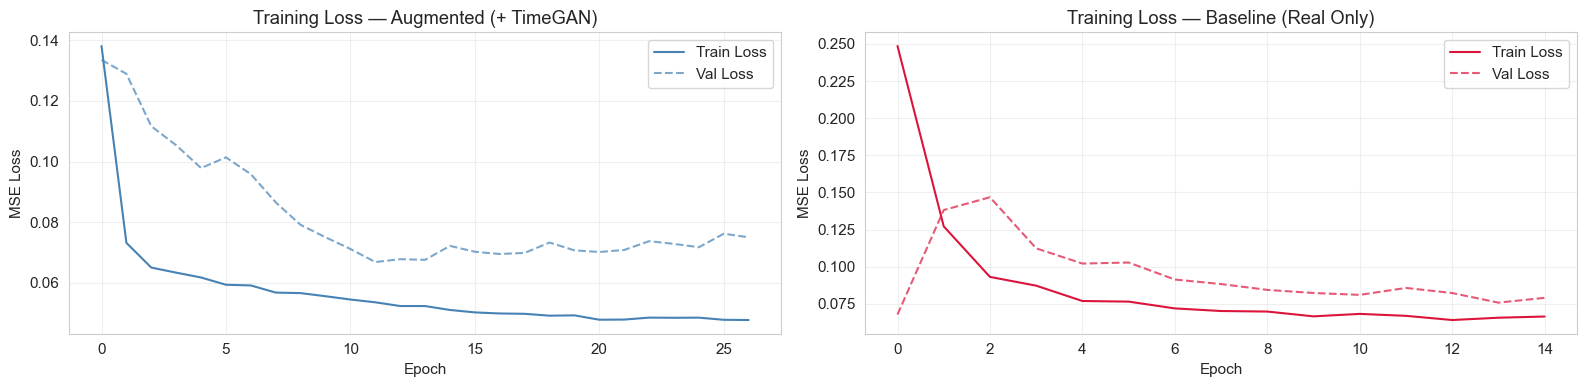

In [60]:
# ── Kurva training loss kedua model ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, hist, label, color in [
    (axes[0], hist_aug,  'Augmented (+ TimeGAN)', 'steelblue'),
    (axes[1], hist_base, 'Baseline (Real Only)',  'crimson'),
]:
    ax.plot(hist.history['loss'],     label='Train Loss', color=color)
    ax.plot(hist.history['val_loss'], label='Val Loss',   color=color, linestyle='--', alpha=0.7)
    ax.set_title(f'Training Loss — {label}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

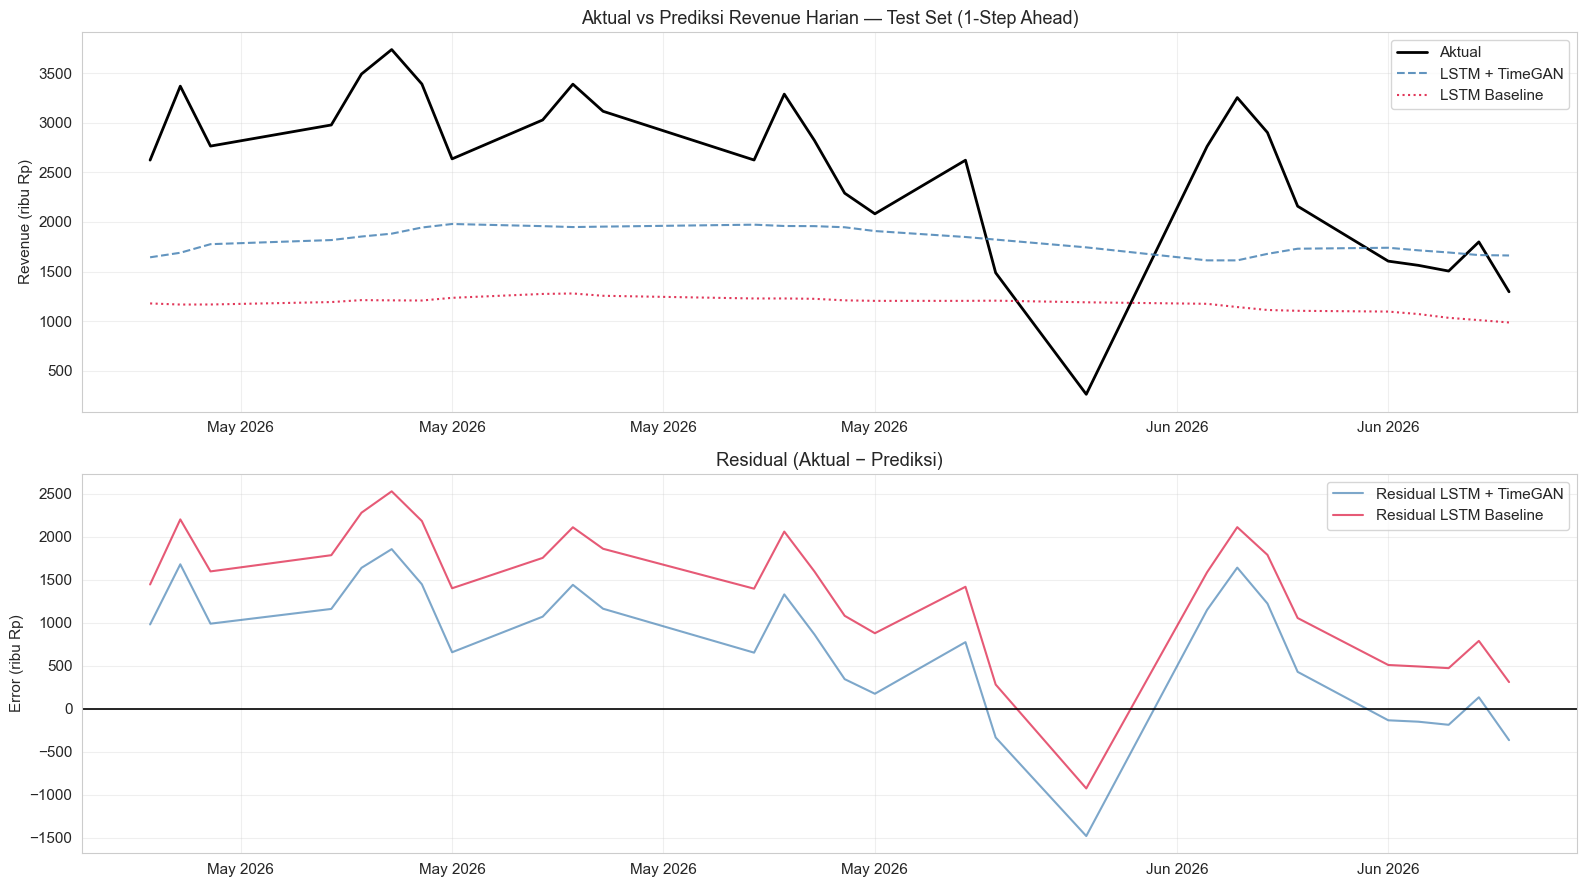

In [61]:
# ── Actual vs Predicted pada Test Set (1-step ahead) ────────────────────────
y_true_plot = res_aug['y_true'][:, 0]
y_aug_plot  = res_aug['y_pred'][:, 0]
y_base_plot = res_base['y_pred'][:, 0]

start_idx  = n_train + n_val + LOOK_BACK
test_dates = df_real.iloc[start_idx : start_idx + len(y_true_plot)]['date'].values

fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# — Panel atas: perbandingan kedua model —
ax = axes[0]
ax.plot(test_dates, y_true_plot / 1e3,  label='Aktual',              color='black',     linewidth=2)
ax.plot(test_dates, y_aug_plot  / 1e3,  label='LSTM + TimeGAN',      color='steelblue', linewidth=1.5, linestyle='--', alpha=0.85)
ax.plot(test_dates, y_base_plot / 1e3,  label='LSTM Baseline',       color='crimson',   linewidth=1.5, linestyle=':',  alpha=0.85)
ax.set_title('Aktual vs Prediksi Revenue Harian — Test Set (1-Step Ahead)', fontsize=13)
ax.set_ylabel('Revenue (ribu Rp)')
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# — Panel bawah: residual kedua model —
ax = axes[1]
ax.plot(test_dates, (y_true_plot - y_aug_plot)  / 1e3,
        label='Residual LSTM + TimeGAN', color='steelblue', alpha=0.7)
ax.plot(test_dates, (y_true_plot - y_base_plot) / 1e3,
        label='Residual LSTM Baseline',  color='crimson',   alpha=0.7)
ax.axhline(0, color='black', linewidth=1.2)
ax.set_title('Residual (Aktual − Prediksi)')
ax.set_ylabel('Error (ribu Rp)')
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()

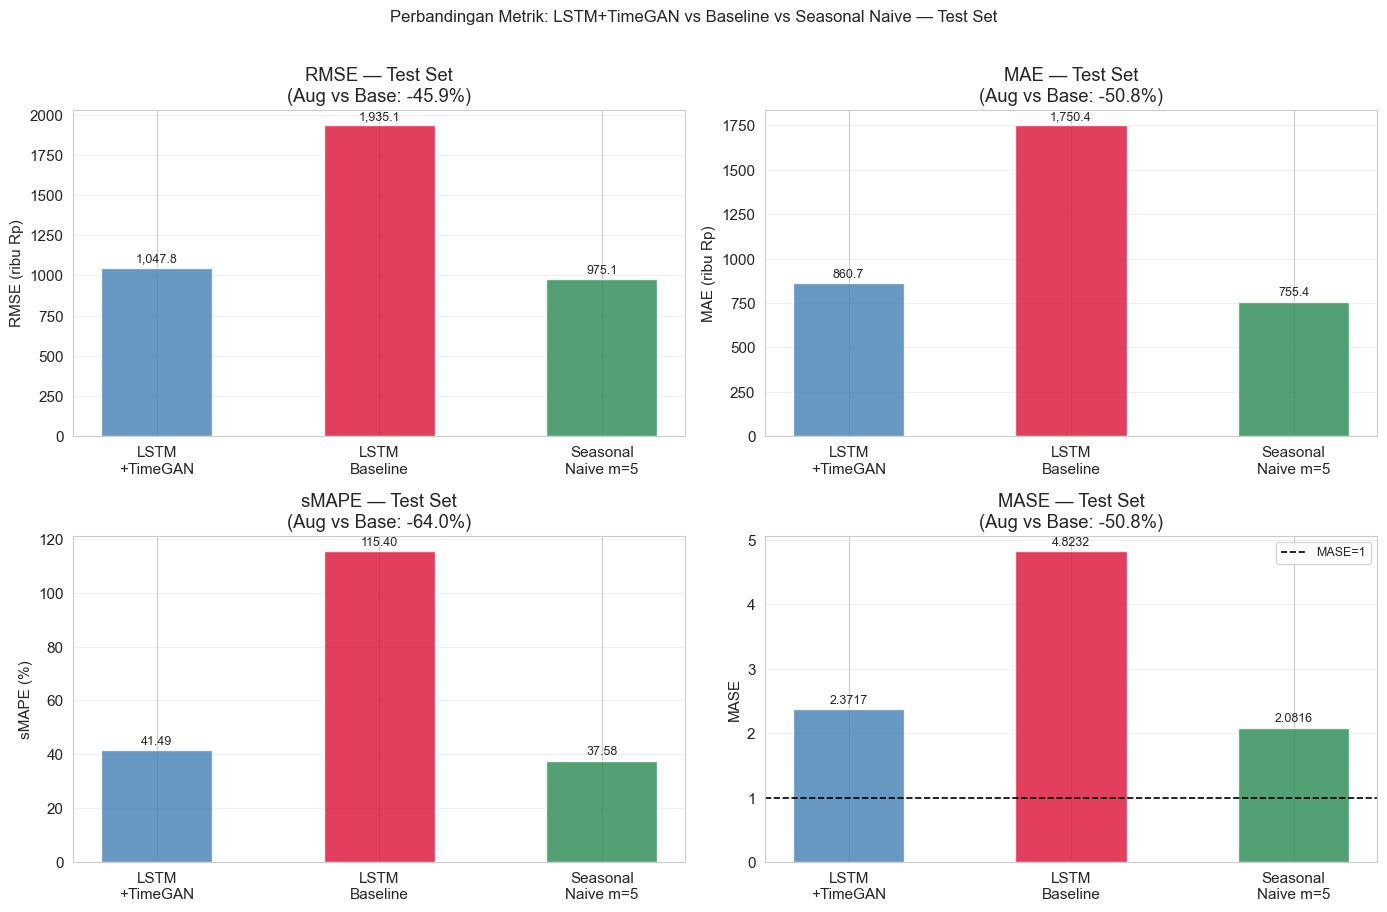


=== KESIMPULAN ===
✓ TimeGAN augmentasi MENINGKATKAN vs Baseline  : MAE turun 50.83%
✗ LSTM + TimeGAN KALAH dari Seasonal Naive m=5 : MAE lebih tinggi 13.94%

MASE h=1  → Aug: 2.5053  |  SN5: 2.1403  |  >1 (kalah naive-1step)


In [62]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

models = ['LSTM\n+TimeGAN', 'LSTM\nBaseline', 'Seasonal\nNaive m=5']
colors = ['steelblue', 'crimson', 'seagreen']

metrics_cfg = [
    ('RMSE',  [res_aug['rmse'],  res_base['rmse'],  res_sn5['rmse']],  'ribu Rp', 1e3),
    ('MAE',   [res_aug['mae'],   res_base['mae'],   res_sn5['mae']],   'ribu Rp', 1e3),
    ('sMAPE', [res_aug['smape'], res_base['smape'], res_sn5['smape']], '%',        1.0),
    ('MASE',  [res_aug['mase'],  res_base['mase'],  res_sn5['mase']],  '',         1.0),
]

x  = np.arange(len(models))
w  = 0.5

for ax, (metric, vals, unit, div) in zip(axes, metrics_cfg):
    bars = ax.bar(x, [v / div for v in vals], w, color=colors, alpha=0.82)

    for bar, val in zip(bars, [v / div for v in vals]):
        fmt = (f'{val:,.1f}' if div == 1e3
               else f'{val:.4f}' if metric == 'MASE'
               else f'{val:.2f}')
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max([v/div for v in vals]) * 0.01,
                fmt, ha='center', va='bottom', fontsize=9)

    # Anotasi delta augmented vs baseline
    delta = (vals[0] - vals[1]) / vals[1] * 100
    sign  = '+' if delta > 0 else ''
    ax.set_title(f'{metric} — Test Set\n(Aug vs Base: {sign}{delta:.1f}%)')
    ax.set_ylabel(f'{metric} ({unit})' if unit else metric)
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.grid(alpha=0.3, axis='y')

    if metric == 'MASE':
        ax.axhline(1.0, color='black', linestyle='--', linewidth=1.2, label='MASE=1')
        ax.legend(fontsize=9)

plt.suptitle('Perbandingan Metrik: LSTM+TimeGAN vs Baseline vs Seasonal Naive — Test Set',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print('\n=== KESIMPULAN ===')
if res_aug['mae'] < res_base['mae']:
    d = (res_base['mae'] - res_aug['mae']) / res_base['mae'] * 100
    print(f'✓ TimeGAN augmentasi MENINGKATKAN vs Baseline  : MAE turun {d:.2f}%')
else:
    d = (res_aug['mae'] - res_base['mae']) / res_base['mae'] * 100
    print(f'✗ TimeGAN augmentasi TIDAK meningkatkan vs Baseline: MAE naik {d:.2f}%')

if res_aug['mae'] < res_sn5['mae']:
    d = (res_sn5['mae'] - res_aug['mae']) / res_sn5['mae'] * 100
    print(f'✓ LSTM + TimeGAN MENGALAHKAN Seasonal Naive m=5: MAE lebih rendah {d:.2f}%')
else:
    d = (res_aug['mae'] - res_sn5['mae']) / res_sn5['mae'] * 100
    print(f'✗ LSTM + TimeGAN KALAH dari Seasonal Naive m=5 : MAE lebih tinggi {d:.2f}%')

# Ringkasan h=1 (horizon paling relevan)
h1_aug  = ph_df.loc[ph_df['horizon']=='h+1', 'mase_aug'].values[0]
h1_sn5  = ph_df.loc[ph_df['horizon']=='h+1', 'mase_sn5'].values[0]
print(f'\nMASE h=1  → Aug: {h1_aug:.4f}  |  SN5: {h1_sn5:.4f}  |  {"<1 ✓" if h1_aug < 1 else f">1 (kalah naive-1step)"}')

---
## SECTION 7 — Simpan Hasil Perbandingan

In [63]:
result_df = pd.DataFrame([
    {
        'model'      : 'LSTM_Augmented_TimeGAN',
        'train_data' : f'real({len(df_real_train)}) + synthetic({len(X_syn)}seq)',
        'synth_ratio': SYNTH_RATIO,
        'look_back'  : LOOK_BACK, 'horizon': HORIZON,
        'test_rmse'  : round(res_aug['rmse'],  2),
        'test_mae'   : round(res_aug['mae'],   2),
        'test_mape'  : round(res_aug['mape'],  4),
        'test_smape' : round(res_aug['smape'], 4),
        'test_mase'  : round(res_aug['mase'],  4),
        'mase_h1'    : round(ph_df.loc[0, 'mase_aug'], 4),
        'naive_mae'  : round(naive_mae, 2),
    },
    {
        'model'      : 'LSTM_Baseline_RealOnly',
        'train_data' : f'real({len(df_real_train)})',
        'synth_ratio': 0,
        'look_back'  : LOOK_BACK, 'horizon': HORIZON,
        'test_rmse'  : round(res_base['rmse'],  2),
        'test_mae'   : round(res_base['mae'],   2),
        'test_mape'  : round(res_base['mape'],  4),
        'test_smape' : round(res_base['smape'], 4),
        'test_mase'  : round(res_base['mase'],  4),
        'mase_h1'    : round(ph_df.loc[0, 'mase_base'], 4),
        'naive_mae'  : round(naive_mae, 2),
    },
    {
        'model'      : 'Seasonal_Naive_m5',
        'train_data' : 'n/a',
        'synth_ratio': 0,
        'look_back'  : 5, 'horizon': HORIZON,
        'test_rmse'  : round(res_sn5['rmse'],  2),
        'test_mae'   : round(res_sn5['mae'],   2),
        'test_mape'  : round(res_sn5['mape'],  4),
        'test_smape' : round(res_sn5['smape'], 4),
        'test_mase'  : round(res_sn5['mase'],  4),
        'mase_h1'    : round(ph_df.loc[0, 'mase_sn5'], 4),
        'naive_mae'  : round(naive_mae, 2),
    },
    {
        'model'      : 'Seasonal_Naive_m7',
        'train_data' : 'n/a',
        'synth_ratio': 0,
        'look_back'  : 7, 'horizon': HORIZON,
        'test_rmse'  : round(res_sn7['rmse'],  2),
        'test_mae'   : round(res_sn7['mae'],   2),
        'test_mape'  : round(res_sn7['mape'],  4),
        'test_smape' : round(res_sn7['smape'], 4),
        'test_mase'  : round(res_sn7['mase'],  4),
        'mase_h1'    : round(ph_df.loc[0, 'mase_sn7'], 4),
        'naive_mae'  : round(naive_mae, 2),
    },
])

result_path = os.path.join(MODEL_DIR, 'comparison_results.csv')
result_df.to_csv(result_path, index=False)

# Simpan juga per-horizon breakdown
ph_path = os.path.join(MODEL_DIR, 'per_horizon_mase.csv')
ph_df.to_csv(ph_path, index=False)

print('Hasil tersimpan:')
print(f'  {result_path}')
print(f'  {ph_path}')
print()
cols_show = ['model', 'test_mae', 'test_smape', 'test_mase', 'mase_h1']
print(result_df[cols_show].to_string(index=False))
print()
print('Per-horizon MASE (aug | base | sn5):')
print(ph_df[['horizon','mase_aug','mase_base','mase_sn5']].to_string(index=False))

Hasil tersimpan:
  ..\Models\TimeGAN\comparison_results.csv
  ..\Models\TimeGAN\per_horizon_mase.csv

                 model   test_mae  test_smape  test_mase  mase_h1
LSTM_Augmented_TimeGAN  860694.80     41.4946     2.3717   2.5053
LSTM_Baseline_RealOnly 1750355.09    115.4033     4.8232   3.9277
     Seasonal_Naive_m5  755403.06     37.5794     2.0816   2.1403
     Seasonal_Naive_m7  783178.57     38.2350     2.1581   2.2738

Per-horizon MASE (aug | base | sn5):
horizon  mase_aug  mase_base  mase_sn5
    h+1  2.505299   3.927690  2.140290
    h+2  2.563243   4.791903  2.139306
    h+3  2.316583   5.017148  2.082374
    h+4  2.340984   6.002796  2.063380
    h+5  2.452801   5.304222  2.040548
    h+6  2.299322   5.184541  2.092855
    h+7  2.123699   3.534279  2.012205
